# Accessibility & Validation

A good scientific figure should be readable by everyone, including people with color blindness and readers of black-and-white printed journals.

This notebook shows you how to check for both, and how to validate a figure against journal submission rules.

**What you'll learn:**
- Preview how your figure looks to someone with color blindness using `preview_colorblind()`
- Preview how your figure looks in grayscale (black & white) using `preview_grayscale()`
- Programmatically check whether your colors are safe for grayscale printing
- Run a full validation check with `plotstyle.validate()`
- Read and use the individual check results

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import plotstyle

## 1. Create a Sample Figure

First, let's create a figure with multiple colored lines. This is exactly the kind of plot where accessibility matters most, since readers need to be able to tell the lines apart.

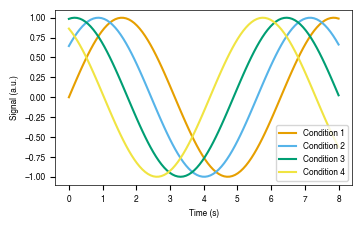

In [2]:
# Retrieve 4 colors from Nature's Okabe-Ito palette
colors = plotstyle.palette("nature", n=4)
x = np.linspace(0, 8, 100)

with plotstyle.use("nature"):
    fig, ax = plotstyle.figure("nature", columns=1)
    for i, c in enumerate(colors):
        ax.plot(x, np.sin(x + i * 0.7), color=c, linewidth=1.5, label=f"Condition {i + 1}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Signal (a.u.)")
    ax.legend()
    plt.show()

## 2. Colorblind Simulation

About 8% of men have some form of color blindness.  `plotstyle.preview_colorblind(fig)` shows you how your figure looks to people with three common types:

| Type | What's affected | How common |
|---|---|---|
| **Deuteranopia** | Can't distinguish green | ~6% of males |
| **Protanopia** | Can't distinguish red | ~2% of males |
| **Tritanopia** | Can't distinguish blue | very rare |

The output is a side-by-side comparison: your original figure plus one panel for each type.

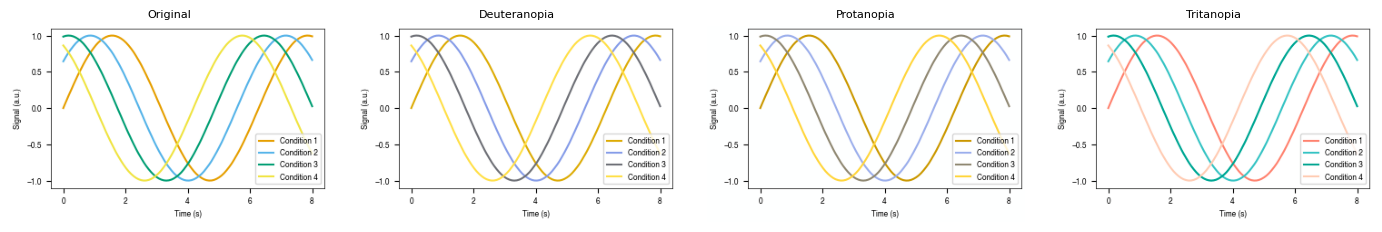

In [3]:
# Side-by-side: original + deuteranopia + protanopia + tritanopia
cvd_fig = plotstyle.preview_colorblind(fig)
plt.show()

## 3. Grayscale Preview

Some journals (like IEEE) print figures in black and white.  `plotstyle.preview_grayscale(fig)` shows your figure as it would appear in print.

If data series look the same shade of gray, readers won't be able to tell them apart.  In that case, consider adding different line styles or markers; you can get these automatically with `plotstyle.palette(..., with_markers=True)`.

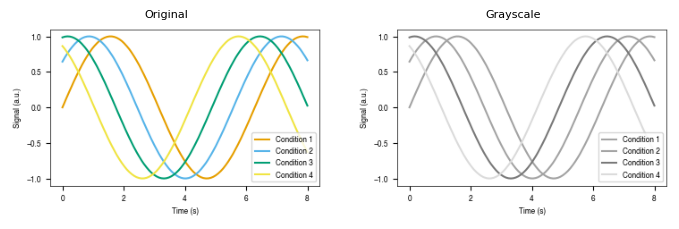

In [4]:
# Side-by-side: original + grayscale luminance rendering
gray_fig = plotstyle.preview_grayscale(fig)
plt.show()
plt.close(fig)  # release the original figure

## 4. Check Grayscale Safety in Code

Instead of visually inspecting a preview, you can check programmatically whether your colors are distinct enough when printed in black and white.

Two helper functions make this easy:
- `is_grayscale_safe(colors)`: returns `True` if all colors are sufficiently different in brightness.
- `luminance_delta(colors)`: returns how different each pair of colors is in brightness, sorted from most similar to most different.

In [ ]:
from plotstyle.color.grayscale import is_grayscale_safe, luminance_delta

palette_colors = plotstyle.palette("nature", n=4)

# Threshold 0.10 = every pair must differ by >= 10 % of the luminance scale
safe = is_grayscale_safe(palette_colors, threshold=0.1)
print(f"Nature palette grayscale-safe (threshold=0.1): {safe}")

# Inspect individual pair deltas, sorted ascending so the weakest pair is first
deltas = luminance_delta(palette_colors)
print("\nPairwise luminance deltas (sorted ascending):")
for i, j, delta in deltas:
    status = "✓" if delta >= 0.1 else "✗"
    print(f"  {status}  Color {i} vs Color {j}: Δ = {delta:.3f}")

## 5. Run a Full Validation

`plotstyle.validate(fig, journal="nature")` runs all checks in one go: dimensions, fonts, colors, line weights, and export settings.  Each check results in a `PASS`, `FAIL`, or `WARN`.

In [6]:
with plotstyle.use("nature"):
    fig, ax = plotstyle.figure("nature", columns=1)
    colors = plotstyle.palette("nature", n=3)
    rng = np.random.default_rng(0)
    for i, c in enumerate(colors):
        ax.plot(np.arange(20), rng.normal(i, 0.5, 20), color=c)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Value")

    # Human-readable ASCII table printed to stdout
    report = plotstyle.validate(fig, journal="nature")
    print(report)
    plt.close(fig)

┌──────────────────────────────────────────────────────┐
│         PlotStyle Validation Report — Nature         │
├──────────┬───────────────────────────────────────────┤
│ ✓ PASS   │ No red-green colour pair detected.        │
│ ⚠ WARN   │ One or more axes contain multiple data ...│
│ ✓ PASS   │ Figure width 89.0mm matches single colu...│
│ ✓ PASS   │ Figure height 55.0mm is within the Natu...│
│ ✓ PASS   │ pdf.fonttype = 42 (TrueType fonts will ...│
│ ✓ PASS   │ ps.fonttype = 42 (TrueType fonts will b...│
│ ✓ PASS   │ savefig.dpi = 300.0 meets the Nature mi...│
│ ✓ PASS   │ All plotted lines and spines meet the N...│
│ ✓ PASS   │ All text elements are within the Nature...│
└──────────┴───────────────────────────────────────────┘
8/9 checks passed, 1 warning(s), 0 failure(s)


## 6. Read Individual Check Results

The report object gives you access to each check result individually, which is useful if you want to loop over them, filter for failures, or save the results to a file.

- `report.passed`: `True` if the figure passed all checks
- `report.checks`: every check result
- `report.failures`: only the failed checks
- `report.to_dict()`: the full report as a plain dictionary (easy to save as JSON)

In [ ]:
print(f"Overall passed: {report.passed}")
print(f"Total checks: {len(report.checks)}\n")

# Iterate over every check result with a status icon
for result in report.checks:
    icon = {"PASS": "✓", "FAIL": "✗", "WARN": "⚠"}[result.status.value]
    print(f"{icon} [{result.check_name}] {result.message}")
    if result.fix_suggestion:
        print(f"   Fix: {result.fix_suggestion}")

# Serialize to a plain dict, ready for json.dumps() in a CI pipeline
report_dict = report.to_dict()
print(f"\nReport dict keys: {list(report_dict.keys())}")